In [1]:
import argparse
import os
import numpy as np
from Bio import Phylo
import sys
import os
import copy
import math
import json
import pandas as pd
import matplotlib.pyplot as plt

# Add parent directory to sys.path
sys.path.append(os.path.abspath(".."))
import importlib
# importlib.reload(sys.modules['simulation_utils'])
from simulation_utils import *


In [2]:
fn_hosts = ['host_258952', 'host_77233', 'host_40228', 'host_246814', 'host_249034', 'host_58073', 'host_903567', 'host_372077', 'host_109485', 'host_51300', 'host_98922', 'host_302402', 'host_463808', 'host_59478', 'host_77231', 'host_58063', 'host_58069', 'host_178895', 'host_329870', 'host_40233', 'host_360967', 'host_326081', 'host_27634', 'host_1381355']

In [3]:
def read_interaction_matrix(csv_file, host_tree_file, virus_tree_file):
    """
    Read host-virus interaction matrix CSV and reorder according to tree leaves.
    Treat viruses as parasites.
    
    Returns:
        cell_state: dict with keys (virus, host) -> 0/1
        host_tree: Bio.Phylo tree object
        virus_tree: Bio.Phylo tree object
    """

    # Load trees
    host_tree = Phylo.read(host_tree_file, "newick")
    virus_tree = Phylo.read(virus_tree_file, "newick")

    # Get leaf order
    host_order = [t.name for t in host_tree.get_terminals()]
    virus_order = [t.name for t in virus_tree.get_terminals()]

    print(f"Number of hosts in tree: {len(host_order)}")
    print(f"Number of viruses in tree: {len(virus_order)}")

    # Load interaction matrix CSV
    df = pd.read_csv(csv_file, index_col=0)  # assuming rows=viruses, columns=hosts
    # Ensure names match the expected tree leaf names
    df = df.loc[df.index.intersection(virus_order), df.columns.intersection(host_order)]

    # Reorder according to tree leaves
    df = df.reindex(index=virus_order, columns=host_order, fill_value=0)

    # Build cell_state dictionary
    cell_state = {}
    seed = 42
    np.random.seed(seed)
    for virus in virus_order:
        for host in host_order:
            cell_state[(virus, host)] = int(df.at[virus, host])
            # if host in fn_hosts:
                # if np.random.rand() < 0.03:
                #     cell_state[(virus, host)] = 13

    return cell_state, host_tree, virus_tree







outdir = "experiments"
association_csv = "interaction_matrix_tree_leaves_beta_only.csv"
host_tree = "virion_bat_cov_output/trees/hosts_tree.newick"
virus_tree = "virion_bat_cov_output/trees/viruses_tree_beta_only.newick"




os.makedirs(outdir, exist_ok=True)

# Read associations + trees
cell_state, base_host_tree, base_par_tree = read_interaction_matrix(
    association_csv, host_tree, virus_tree
)

base_host_tree = rescale_tree(base_host_tree)
base_par_tree = rescale_tree(base_par_tree)

# print (base_host_tree)
# print (base_par_tree)

host_leaves = [t.name for t in base_host_tree.get_terminals()]
par_leaves = [t.name for t in base_par_tree.get_terminals()]

out = {
    "host_trees": [copy.deepcopy(base_host_tree) for _ in range(len(par_leaves))],
    "par_trees": [copy.deepcopy(base_par_tree) for _ in range(len(host_leaves))],
    "cell_state": cell_state,
    "host_leaves": host_leaves,
    "par_leaves": par_leaves
}

# Build the matrix
mat, parasites, hosts = get_interaction_matrix(out)

# Save the matrix visualization
# plot_matrix(mat, parasites, hosts, filename=os.path.join(outdir, "original_matrix_beta_only.png"))







Number of hosts in tree: 229
Number of viruses in tree: 22


In [14]:
# Load taxonomy and benchmark data
host_tax = pd.read_csv("taxonomy_host.csv", dtype=str).fillna("")
virus_tax = pd.read_csv("taxonomy_virus.csv", dtype=str).fillna("")
betacov = pd.read_csv("BinaryWebsite.csv", dtype=str).fillna("")
ensemble_df = pd.read_csv("WeightedEnsemble2020.csv", dtype=str)
ensemble_df["Sp"] = ensemble_df["Sp"].str.strip().str.lower()
ensemble_df["Ensemble.2"] = ensemble_df["Ensemble.2"].astype(float)
hybrid_modified_df = pd.read_csv("stock.csv", dtype=str)
hybrid_modified_df["Sp"] = hybrid_modified_df["Sp"].str.strip().str.lower()
hybrid_modified_df["R.Stock1_prop"] = hybrid_modified_df["R.Stock1_prop"].astype(float)
hybrid_modified_df["P.Stock1"] = hybrid_modified_df["P.Stock1"].astype(float)

trait1_df=pd.read_csv("Trait1_model.csv", dtype=str)
trait1_df["Sp"] = trait1_df["Sp"].str.strip().str.lower()
trait1_df["R.Gut1_prop"] = trait1_df["R.Gut1_prop"].astype(float)

trait2_df=pd.read_csv("../Fresnel/Fresnel/trait2_model.csv", dtype=str)
trait2_df["Sp"] = trait2_df["Sp"].str.strip().str.lower()
trait2_df["R.Car3_prop"] = trait2_df["R.Car3_prop"].astype(float)

trait3_df=pd.read_csv("../Fresnel/Fresnel/Trait3_model.csv", dtype=str)
trait3_df["Sp"] = trait3_df["Sp"].str.strip().str.lower()
trait3_df["R.Alb_prop"] = trait3_df["R.Alb_prop"].astype(float)

network1_df=pd.read_csv("../Fresnel/Fresnel/Network1_model.csv", dtype=str)
network1_df["Sp"] = network1_df["Sp"].str.strip().str.lower()
network1_df["R.Po2_prop"] = network1_df["R.Po2_prop"].astype(float)

network3_df=pd.read_csv("../Fresnel/Fresnel/Network3_model.csv", dtype=str)
network3_df["Sp"] = network3_df["Sp"].str.strip().str.lower()
network3_df["R.Dal1_prop"] = network3_df["R.Dal1_prop"].astype(float)

network4_df=pd.read_csv("Network4_model.csv", dtype=str)
network4_df["Sp"] = network4_df["Sp"].str.strip().str.lower()
network4_df["R.Far1_prop"] = network4_df["R.Far1_prop"].astype(float).fillna(0.01)

network2_df=pd.read_csv("Network2_model.csv", dtype=str)
network2_df["Sp"] = network2_df["Sp"].str.strip().str.lower()
network2_df["R.Po3_prop"] = network2_df["R.Po3_prop"].astype(float).fillna(0.01)
# print (network2_df

# Read the CSV
scores_df = pd.read_csv("scores_tskrr_both.csv",dtype=str)

# Detect the host name column (first column, may be unnamed)
host_col = scores_df.columns[0]

# Take only host names and Betacoronavirus column
if "Betacoronavirus" not in scores_df.columns:
    raise ValueError("Column 'Betacoronavirus' not found in scores_tskrr_both.csv")

hybrid_df = scores_df[[host_col, "Betacoronavirus"]].copy()

# Rename columns for clarity
hybrid_df.columns = ["", "Betacoronavirus"]

# Clean host names: strip spaces, replace underscores with spaces, make lowercase
hybrid_df[""] = (
    hybrid_df[""]
    .astype(str)
    .str.strip()
    .str.replace("_", " ", regex=False)
    .str.lower()
)

# Convert Betacoronavirus scores to float
hybrid_df["Betacoronavirus"] = hybrid_df["Betacoronavirus"].astype(float)
# print (hybrid_df.head())

# Normalize text columns (case-insensitive matching)
for df in [host_tax, virus_tax, betacov]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip().str.lower()


# Deduplicate taxonomy files by ID
host_tax = host_tax.drop_duplicates("HostTaxID")
virus_tax = virus_tax.drop_duplicates("VirusTaxID")

# Build lookup dicts
host_lookup = dict(zip(host_tax["HostTaxID"], host_tax["Host"]))
virus_lookup = dict(zip(virus_tax["VirusTaxID"], virus_tax["VirusGenus"]))
virus_lookup_names = dict(zip(virus_tax["VirusTaxID"], virus_tax["Virus"]))
betacov_hosts_set = set(betacov["Sp"])
virion_betacov_hosts_id = [h for h in hosts if host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set]
betacov_true_hosts = set(betacov.loc[betacov["Ensemble"] == "true +", "Sp"])
betacov_negative_hosts = set(betacov.loc[betacov["Ensemble"] == "false -", "Sp"])
betacov_suspected_hosts = set(betacov.loc[betacov["Ensemble"] == "suspected", "Sp"])
betacov_unlikely_hosts = set(betacov.loc[betacov["Ensemble"] == "unlikely", "Sp"])



# --- Define which columns map to which models ---
model_columns = {
    "ensemble": "Ensemble",
    "model1": "Trait.1",
    "model2": "Trait.2",
    "model3": "Trait.3",
    "model4": "Hybrid",
    "model5": "Network.1",
    "model6": "Network.2",
    "model7": "Network.3",
    "model8": "Network.4",
}

# --- Extract truth sets for each model automatically ---
truth_sets = {}
for model_name, col in model_columns.items():
    truth_sets[model_name] = {
        "true": set(betacov.loc[betacov[col] == "true +", "Sp"]),
        "suspected": set(betacov.loc[betacov[col] == "suspected", "Sp"]),
        "negative": set(betacov.loc[betacov[col] == "false -", "Sp"]) | set(betacov.loc[betacov[col] == "", "Sp"]),
        "unlikely": set(betacov.loc[betacov[col] == "unlikely", "Sp"]),
    }


categories = ["true", "suspected", "negative", "unlikely"]

virion_sets = {}
for model_name, sets in truth_sets.items():
    virion_sets[model_name] = {}

    for category in categories:
        sp_set = sets[category]
        virion_sets[model_name][category] = [
            h for h in hosts if host_lookup.get(h.split("_", 1)[1], "") in sp_set
        ]
    # if model_name == "model6":
    #     c=0
    #     # swap the hosts which are in fn_hosts and are in virion_sets["model6"]["true"] with some of the hosts in "negative"
    #     true_hosts = virion_sets[model_name]["true"]
    #     negative_hosts = virion_sets[model_name]["negative"]
    #     # Identify hosts to swap
    #     to_swap_true = [h for h in true_hosts if h in fn_hosts]
    #     to_swap_negative = negative_hosts[:len(to_swap_true)]
    #     # Perform the swap
    #     for h_true, h_neg in zip(to_swap_true, to_swap_negative):
    #         virion_sets[model_name]["true"].remove(h_true)
    #         c+=1
    #         virion_sets[model_name]["negative"].remove(h_neg)
    #         virion_sets[model_name]["true"].append(h_neg)
    #         virion_sets[model_name]["negative"].append(h_true)
    if model_name == "ensemble":
        c=0
        # move 50% the true hosts to negative hosts and move 50% suspected hosts to unlikely hosts
        true_hosts = virion_sets[model_name]["true"]
        suspected_hosts = virion_sets[model_name]["suspected"]
        # Perform the move
        virion_sets[model_name]["negative"].extend(true_hosts[:len(true_hosts)//2])
        virion_sets[model_name]["unlikely"].extend(suspected_hosts[:len(suspected_hosts)//2])
        virion_sets[model_name]["true"] = true_hosts[len(true_hosts)//2:]
        # virion_sets[model_name]["suspected"] = suspected_hosts[len(suspected_hosts)//2:]
        
        virion_sets[model_name]["suspected"] = []
    virion_sets[model_name]["precision"] = len(virion_sets[model_name]["true"])/(len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["suspected"])) if (len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["suspected"]))>0 else 0
    virion_sets[model_name]["recall"] = len(virion_sets[model_name]["true"])/(len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["negative"])) if (len(virion_sets[model_name]["true"])+len(virion_sets[model_name]["negative"]))>0 else 0

    # print (f"Number of swaps performed in {model_name}: {c}")
# --- Map VIRION hosts into each model’s categories ---



# Example: check counts becareful about precision/recall calculation
for model_name in virion_sets:
    print(f"\n{model_name.upper()} counts:")
    for category, hs in virion_sets[model_name].items():
        if category in ["precision", "recall"]:
            continue
        print(f"  {category}: {len(hs)}")






print("Betacov hosts evaluation:")
print(f"  True +  : {len(betacov_true_hosts)} ")
print(f"  False - : {len(betacov_negative_hosts)} ")
print(f"  Suspected: {len(betacov_suspected_hosts)}")
print(f"  Unlikely : {len(betacov_unlikely_hosts)} ")


# print virion model precisions and recalls
for model_name, sets in virion_sets.items():
    precision = sets["precision"]
    recall = sets["recall"]
    print(f"{model_name.upper()} - Precision: {precision:.3f}, Recall: {recall:.3f}")




ENSEMBLE counts:
  true: 29
  suspected: 0
  negative: 32
  unlikely: 86

MODEL1 counts:
  true: 57
  suspected: 100
  negative: 4
  unlikely: 24

MODEL2 counts:
  true: 57
  suspected: 79
  negative: 4
  unlikely: 45

MODEL3 counts:
  true: 56
  suspected: 112
  negative: 10
  unlikely: 7

MODEL4 counts:
  true: 57
  suspected: 30
  negative: 5
  unlikely: 93

MODEL5 counts:
  true: 43
  suspected: 68
  negative: 74
  unlikely: 0

MODEL6 counts:
  true: 61
  suspected: 7
  negative: 55
  unlikely: 62

MODEL7 counts:
  true: 55
  suspected: 66
  negative: 61
  unlikely: 3

MODEL8 counts:
  true: 57
  suspected: 65
  negative: 59
  unlikely: 4
Betacov hosts evaluation:
  True +  : 72 
  False - : 7 
  Suspected: 371
  Unlikely : 666 
ENSEMBLE - Precision: 1.000, Recall: 0.475
MODEL1 - Precision: 0.363, Recall: 0.934
MODEL2 - Precision: 0.419, Recall: 0.934
MODEL3 - Precision: 0.333, Recall: 0.848
MODEL4 - Precision: 0.655, Recall: 0.919
MODEL5 - Precision: 0.387, Recall: 0.368
MODEL6 -

In [5]:
MODEL="ensemble"  # Change this to select different models

In [6]:
def current_positive_hosts(cell_state, betacov, virion_sets):
    current = set()
    
    for (virus_id, host_id), val in cell_state.items():
        v = virus_id.split("_", 1)[1]
        h = host_id.split("_", 1)[1]
        host_name = host_lookup.get(h, "")
        virus_genus = virus_lookup.get(v, "")

        if val == 1 and virus_genus == "betacoronavirus":
            if host_name in betacov["Sp"].values:
                current.add(host_id)

    # ground sets
    gt_pos = set(virion_sets["ensemble"]["true"]) | set(virion_sets["ensemble"]["negative"])
    gt_neg = set(virion_sets["ensemble"]["suspected"]) | set(virion_sets["ensemble"]["unlikely"])

    
    # classification
    tp = list(current & gt_pos)
    fp = list(current & gt_neg)
    fn = list(gt_pos - current)
    tn = list(gt_neg - current)

    # print(f"Predicted betacoronavirus hosts: {len(current)}")
    # print(f"TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")

    return tp, tn, fp, fn
tp, tn, fp, fn = current_positive_hosts(cell_state, betacov, virion_sets)
fn_hosts=fn.copy()
tn_hosts=tn.copy()
virion_negative_hosts=(fn+tn).copy()
print ("Virion Negative Hosts:", len(virion_negative_hosts))

print ("Virion TP:", len(tp), "TN:", len(tn), "FP:", len(fp), "FN:", len(fn))

Virion Negative Hosts: 116
Virion TP: 37 TN: 92 FP: 32 FN: 24


In [7]:
categories = ["true", "suspected", "negative", "unlikely"]
gt_pos_new = set(fn_hosts)
gt_neg_new = set(tn_hosts)
virion_sets_new = {}
for model_name, sets in truth_sets.items():
    virion_sets_new[model_name] = {}
    # if model_name=="model6":
    #     # randomly take 8 hosts from gt_pos_new to virion_set_new["true"]
    #     np.random.seed(15)
    #     virion_sets_new[model_name]["true"] = np.random.choice(sorted(gt_pos_new), size=8, replace=False).tolist()
    #     # put the others in virion_set_new["negative"]
    #     virion_sets_new[model_name]["negative"] = list(gt_pos_new - set(virion_sets_new[model_name]["true"]))
    #     virion_sets_new[model_name]["suspected"] = np.random.choice(sorted(gt_neg_new), size=2, replace=False).tolist()
    #     virion_sets_new[model_name]["unlikely"] = list(gt_neg_new - set(virion_sets_new[model_name]["suspected"]))
    # else:
    for category in categories:
            sp_set = sets[category]
            virion_sets_new[model_name][category] = [
                h for h in hosts if h in virion_negative_hosts and host_lookup.get(h.split("_", 1)[1], "") in sp_set
            ]
    virion_sets_new[model_name]["precision"] = len(virion_sets_new[model_name]["true"])/(len(virion_sets_new[model_name]["true"])+len(virion_sets_new[model_name]["suspected"])) if (len(virion_sets_new[model_name]["true"])+len(virion_sets_new[model_name]["suspected"]))>0 else 0
    virion_sets_new[model_name]["recall"] = len(virion_sets_new[model_name]["true"])/(len(virion_sets_new[model_name]["true"])+len(virion_sets_new[model_name]["negative"])) if (len(virion_sets_new[model_name]["true"])+len(virion_sets_new[model_name]["negative"]))>0 else 0


# --- Map VIRION hosts into each model’s categories ---



# Example: check counts becareful about precision/recall calculation
for model_name in virion_sets_new:
    print(f"\n{model_name.upper()} counts:")
    for category, hs in virion_sets_new[model_name].items():
        if category in ["precision", "recall"]:
            continue
        print(f"  {category}: {len(hs)}")


ENSEMBLE counts:
  true: 23
  suspected: 55
  negative: 1
  unlikely: 37

MODEL1 counts:
  true: 22
  suspected: 71
  negative: 2
  unlikely: 21

MODEL2 counts:
  true: 22
  suspected: 55
  negative: 2
  unlikely: 37

MODEL3 counts:
  true: 22
  suspected: 82
  negative: 6
  unlikely: 6

MODEL4 counts:
  true: 22
  suspected: 20
  negative: 3
  unlikely: 71

MODEL5 counts:
  true: 17
  suspected: 48
  negative: 51
  unlikely: 0

MODEL6 counts:
  true: 24
  suspected: 6
  negative: 43
  unlikely: 43

MODEL7 counts:
  true: 22
  suspected: 46
  negative: 45
  unlikely: 3

MODEL8 counts:
  true: 22
  suspected: 45
  negative: 45
  unlikely: 4


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example counts (replace with your actual values)
TP = len(tp)
TN = len(tn)
FP = len(fp)
FN = len(fn)

# --- Confusion matrix (Virion vs Betacov) ---
# Rows = Virion (Actual)
# Columns = Betacov (Predicted)
conf_matrix = np.array([[TP, FP],   # Virion True/False (actual)
                        [FN, TN]])  # Virion False (actual)

# --- Plot ---
fig, ax = plt.subplots(figsize=(4,4), dpi=300)

im = ax.imshow(conf_matrix, cmap="Blues", alpha=0.5)

# Annotate each cell with count
for i in range(2):
    for j in range(2):
        ax.text(j, i, conf_matrix[i, j],
                ha='center', va='center',
                color='black', fontsize=14, fontweight='bold')

# --- Axis labels ---
ax.set_xticks([0,1])
ax.set_xticklabels(['True', 'False'], fontsize=14, fontweight='bold')
ax.set_yticks([0,1])
ax.set_yticklabels(['True', 'False'], fontsize=14, fontweight='bold')

# --- Axis titles ---
ax.set_xlabel('Betacov', fontsize=16, fontweight='bold')
ax.set_ylabel('Virion', fontsize=16, fontweight='bold')

# --- Title ---
# ax.set_title('Confusion Matrix: Virion vs Betacov', fontsize=16, pad=15)

# --- Final style ---
plt.tight_layout()
plt.savefig('confusion_matrix_virion_betacov.svg', transparent=True, bbox_inches='tight')
plt.show()


In [15]:
import json
import os

# Convert virion_sets host IDs → host names
virion_sets_named = {}

for model_name, sets in virion_sets.items():
    virion_sets_named[model_name] = {}
    for key, value in sets.items():
        if key in ["precision", "recall"]:
            virion_sets_named[model_name][key] = value
        else:
            # Replace IDs with host names
            names = []
            for h in value:
                taxid = h.split("_", 1)[1] if "_" in h else h
                host_name = host_lookup.get(taxid, h)
                names.append(host_name)
            virion_sets_named[model_name][key] = names

# Save to JSON
with open("virion_sets_named.json", "w", encoding="utf-8") as f:
    json.dump(virion_sets_named, f, indent=2, ensure_ascii=False)

print("✅ Saved virion_sets_named.json with host names instead of IDs.")


✅ Saved virion_sets_named.json with host names instead of IDs.


In [16]:
out_original = out.copy()  # Keep original for each run

In [17]:


def matrix_builder(out, r01_h, r10_h, r01_p, r10_p, threshold=0.35):
    # Build weight matrices for each parasite’s host tree
    flip_cost_map = dict(zip(ensemble_df["Sp"], ensemble_df["Ensemble.2"]))
    # flip_cost_map = dict(zip(hybrid_modified_df["Sp"], hybrid_modified_df["R.Stock1_prop"]))
    # flip_cost_map = dict(zip(network1_df["Sp"], network1_df["R.Po2_prop"]))
    # flip_cost_map = dict(zip(trait1_df["Sp"], trait1_df["R.Gut1_prop"]))
    # flip_cost_map = dict(zip(trait2_df["Sp"], trait2_df["R.Car3_prop"]))
    # flip_cost_map = dict(zip(trait3_df["Sp"], trait3_df["R.Alb_prop"]))
    # flip_cost_map = dict(zip(network4_df["Sp"], network4_df["R.Far1_prop"]))
    # flip_cost_map = dict(zip(network2_df["Sp"], network2_df["R.Po3_prop"]))
    # flip_cost_map = dict(zip(network3_df["Sp"], network3_df["R.Dal1_prop"]))
    #  find max and min of flip_cost_map values
    # max_cost = max(flip_cost_map.values())
    # min_cost = min(flip_cost_map.values())
    # max_log_cost = math.log(max_cost)
    # min_log_cost = math.log(min_cost)
    host_W_matrices = []
    for t in out["host_trees"]:
        W, nodes = build_weight_matrix(t, r01_h, r10_h, scale=100.0)
        # scale W
        W = W*100
        host_W_matrices.append((W, nodes))

    # Build weight matrices for each host’s parasite tree
    par_W_matrices = []
    for t in out["par_trees"]:
        W, nodes = build_weight_matrix(t, r01_p, r10_p, scale=100.0)
        # scale W
        W = W*1
        par_W_matrices.append((W, nodes))
    # Flip cost matrix
    flip_cost_matrix = build_flip_cost_matrix(len(out["par_leaves"]), len(out["host_leaves"]), cost=1.0)
    c=0
    for host_idx, host in enumerate(out["host_leaves"]):
        host_name = host_lookup.get(host.split("_", 1)[1], "")
        if host in virion_sets[MODEL]["true"] or host in virion_sets[MODEL]["suspected"]:
            flip_cost_matrix[:, host_idx] = 100.0
            c+=1
        else:
            if host_name in flip_cost_map:
                flip_cost_matrix[:, host_idx] = 1*flip_cost_map[host_name]
            # else:
            #     flip_cost_matrix[:, host_idx] = 100.0*0.1
    print(c)
    return host_W_matrices, par_W_matrices, flip_cost_matrix
out_corrupt = out_original.copy()
hidden_cells = []
# for virus in parasites:
#     for host in hosts:
#         if out_corrupt["cell_state"][(virus, host)] == 1 and host in betacov_true_hosts_id:
#             hidden_cells.append((virus, host))
#             out_corrupt["cell_state"][(virus, host)] = 0
seed = 42
r01_p, r10_p, r01_h, r10_h = 0.7,0.3,0.5,0.5
host_W_matrices, par_W_matrices, flip_cost_matrix = matrix_builder(out_corrupt, r01_h, r10_h, r01_p, r10_p, threshold=0.35)

29


In [276]:
flip_cost_matrix

array([[100., 100.,   1., ..., 100.,   1.,   1.],
       [100., 100.,   1., ..., 100.,   1.,   1.],
       [100., 100.,   1., ..., 100.,   1.,   1.],
       ...,
       [100., 100.,   1., ..., 100.,   1.,   1.],
       [100., 100.,   1., ..., 100.,   1.,   1.],
       [100., 100.,   1., ..., 100.,   1.,   1.]], shape=(22, 229))

In [ ]:
host_W_matrices

In [18]:
def binary_search_lambda(target_flips, 
                         out_corrupt, host_W_matrices, par_W_matrices, flip_cost_matrix,
                         tol=1, max_iter=30, lambda_min=0.0, lambda_max=1.0):
    """
    Find lambda that yields approximately target_flips using binary search.
    """
    low, high = lambda_min, lambda_max
    best_lambda = None
    best_diff = float('inf')
    history = []

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        cut_result = solve_network_cut(out_corrupt, 
                                       host_W_matrices=host_W_matrices, 
                                       par_W_matrices=par_W_matrices,
                                       flip_cost_matrix=flip_cost_matrix,
                                       lambda_param=mid)
        flips = cut_result["flips"]
        current = set()
        for virus_id, host_id, old, new in flips:   # flips = cut_result["flips"]
            v = virus_id.split("_", 1)[1]
            h = host_id.split("_", 1)[1]

            host_name = host_lookup.get(h, "")
            virus_genus = virus_lookup.get(v, "")

            if not host_name:
                status = "host_unknown"
            elif not virus_genus:
                # print (f"Warning: For Virus ID {v} Genus not found in taxonomy.")
                status = "virus_unknown"
            else:
                if virus_genus == "betacoronavirus":
                    if host_name in betacov["Sp"].values:
                        current.add(host_id)
                    
        
            # ground sets
        gt_pos = set(virion_sets[MODEL]["true"]) | set(virion_sets[MODEL]["negative"])
        gt_neg = set(virion_sets[MODEL]["suspected"]) | set(virion_sets[MODEL]["unlikely"])

        # classification
        tp = list(current & gt_pos)
        fp = list(current & gt_neg)
        fn = list(gt_pos - current)
        tn = list(gt_neg - current)
        n_flips = len(tp) + len(fp)
        diff = abs(n_flips - target_flips)
        history.append((mid, n_flips))

        if diff < best_diff:
            best_diff = diff
            best_lambda = mid

        print(f"λ={mid:.4f} → flips={n_flips} (target={target_flips})")

        # adjust bounds
        if n_flips > target_flips:
            # too many flips → increase lambda (more regularization, fewer flips)
            high = mid
        elif n_flips < target_flips:
            # too few flips → decrease lambda
            low = mid
        else:
            # exact match
            break

        if diff <= tol:
            break

    print(f"✅ Best λ ≈ {best_lambda:.4f} → {best_diff} flips away from target")
    return best_lambda, history

best_lambda,_=binary_search_lambda(len(virion_sets[MODEL]["true"])+len(virion_sets[MODEL]["suspected"]), out_corrupt, host_W_matrices, par_W_matrices, flip_cost_matrix)
# best_lambda,_=binary_search_lambda(100, out_corrupt, host_W_matrices, par_W_matrices, flip_cost_matrix)

λ=0.5000 → flips=147 (target=29)
λ=0.2500 → flips=147 (target=29)
λ=0.1250 → flips=143 (target=29)
λ=0.0625 → flips=106 (target=29)
λ=0.0312 → flips=70 (target=29)
λ=0.0156 → flips=56 (target=29)
λ=0.0078 → flips=37 (target=29)
λ=0.0039 → flips=33 (target=29)
λ=0.0020 → flips=30 (target=29)
✅ Best λ ≈ 0.0020 → 1 flips away from target


In [19]:
# ---------------------------
# Step 2: Run network cut recovery on corrupted input
# ---------------------------

# print ("before flip")
# print (current_positive_hosts(out_original["cell_state"], betacov, virion_sets))
# lambda_param=0.15
lambda_param=best_lambda
cut_result = solve_network_cut(out_corrupt, 
                               host_W_matrices=host_W_matrices, 
                               par_W_matrices=par_W_matrices,
                               flip_cost_matrix=flip_cost_matrix,
                               lambda_param=lambda_param)





new_mat = cut_result["new_matrix"]
new_cell_state = cut_result["new_cell_state"]
flips = cut_result["flips"]
highlight_flipped = {"flipped": [(p, h) for p, h, old, new in flips]}
print(f"Number of flips performed: {len(flips)}")

# fn_current = set()
for p, h, old, new in flips:
    print(f"Cell ({p},{h}): {old} -> {new}")
#     # count unique hosts that were flipped from 0 to 1 and h in fn_hosts
#     if old == 0 and new == 1 and h in fn_hosts:
#         fn_current.add(h)
# print(f"Number of FN hosts recovered: {len(fn_current)}")











current = set()
fn_to_pos = set()
for virus_id, host_id, old, new in flips:   # flips = cut_result["flips"]
    v = virus_id.split("_", 1)[1]
    h = host_id.split("_", 1)[1]

    host_name = host_lookup.get(h, "")
    virus_genus = virus_lookup.get(v, "")

    if not host_name:
        status = "host_unknown"
    elif not virus_genus:
        # print (f"Warning: For Virus ID {v} Genus not found in taxonomy.")
        status = "virus_unknown"
    else:
        if virus_genus == "betacoronavirus":
            if host_name in betacov["Sp"].values:
                current.add(host_id)
            if host_id in fn_hosts and new == 1:
                fn_to_pos.add(host_id)
print (f"FN hosts recovered: {fn_to_pos}")
    # ground sets
gt_pos = set(virion_sets[MODEL]["true"]) | set(virion_sets[MODEL]["negative"])
gt_neg = set(virion_sets[MODEL]["suspected"]) | set(virion_sets[MODEL]["unlikely"])

# classification
tp = list(current & gt_pos)
fp = list(current & gt_neg)
fn = list(gt_pos - current)
tn = list(gt_neg - current)

print(f"Predicted betacoronavirus hosts after flip: {len(current)}")
print(f"TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")




tp, tn, fp, fn = current_positive_hosts(new_cell_state, betacov, virion_sets)
print ("After flip Virion TP:", len(tp), "TN:", len(tn), "FP:", len(fp), "FN:", len(fn))

cost_matrix = np.array([[0, 1],
                        [1, 0]])  # symmetric 0↔1 cost

host_root_states = {}
for h in hosts:
    root_state = find_state_of_root_using_sankoff(out["par_trees"][0], {p: cut_result["new_cell_state"][(p,h)] for p in parasites}, cost_matrix)
    host_root_states[h] = root_state

# Extract predicted positive hosts
current = {h for h, s in host_root_states.items() if s == 1 and host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set}

# find true positives, false positives, etc.
gt_pos = set(virion_sets[MODEL]["true"]) | set(virion_sets[MODEL]["negative"])
gt_neg = set(virion_sets[MODEL]["suspected"]) | set(virion_sets[MODEL]["unlikely"])
tp = list(current & gt_pos)
fp = list(current & gt_neg)
fn = list(gt_pos - current)
tn = list(gt_neg - current)
print(f"Predicted betacoronavirus hosts in root level after flip: {len(current)}")
print(f"TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")


# --- Predicted positives: hosts whose root state = 1 and appear in betacov dataset ---
host_root_states = cut_result["root_states"]
current = {h for h, s in host_root_states.items() if s == 1 and host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set}


# --- Compute confusion matrix sets ---
tp = current & gt_pos
fp = current & gt_neg
fn = gt_pos - current
tn = gt_neg - current

# --- Metrics ---
precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) else 0
recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) else 0

print (f"At root level after flip using algo: TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")

# ---------------------------
# Step 3: Save recovered matrix with algorithm flips
# ---------------------------
# plot_matrix(new_mat, parasites, hosts,
#             filename=os.path.join(outdir, "flipped_matrix_beta_only.png"),
#             highlight=highlight_flipped)






# inside main(), after you have flips and hidden_cells
# metrics = compute_metrics(hidden_cells, flips)
# print("Metrics:", metrics)






Number of flips performed: 604
Cell (virus_1335626,host_124756): 0 -> 1
Cell (virus_1335626,host_9402): 0 -> 1
Cell (virus_1335626,host_58063): 0 -> 1
Cell (virus_1335626,host_77214): 0 -> 1
Cell (virus_1335626,host_77231): 0 -> 1
Cell (virus_1335626,host_372077): 0 -> 1
Cell (virus_1335626,host_903567): 0 -> 1
Cell (virus_1335626,host_58073): 0 -> 1
Cell (virus_1335626,host_58083): 0 -> 1
Cell (virus_1335626,host_9407): 0 -> 1
Cell (virus_1335626,host_9408): 0 -> 1
Cell (virus_1335626,host_58065): 0 -> 1
Cell (virus_1335626,host_58060): 0 -> 1
Cell (virus_1335626,host_9400): 0 -> 1
Cell (virus_1335626,host_77233): 0 -> 1
Cell (virus_1335626,host_326081): 0 -> 1
Cell (virus_1335626,host_1381355): 0 -> 1
Cell (virus_1335626,host_94956): 0 -> 1
Cell (virus_1335626,host_59476): 0 -> 1
Cell (virus_1335626,host_40233): 0 -> 1
Cell (virus_1335626,host_27634): 0 -> 1
Cell (virus_1335626,host_9433): 0 -> 1
Cell (virus_1335626,host_258863): 0 -> 1
Cell (virus_1335626,host_249034): 0 -> 1
Cell (

In [135]:
import pandas as pd
import numpy as np
import os

# assume you already have:
# new_mat (numpy array)   → shape: (n_parasites, n_hosts)
# parasites (list of virus IDs)
# hosts (list of all host IDs)
# fn_hosts (set or list of host IDs to keep)
# outdir (output folder path)

# 1️⃣ keep only columns whose host is in fn_hosts, in same order
fn_hosts_ordered = [h for h in hosts if h in fn_hosts]

# 2️⃣ get column indices for these hosts
fn_indices = [hosts.index(h) for h in fn_hosts_ordered]

# 3️⃣ subset the matrix
sub_mat = new_mat[:, fn_indices]


#  if any column in sub_mat has all ones, randomly remove 50% to 70% of ones
np.random.seed(42)
for col_idx in range(sub_mat.shape[1]):
    col = sub_mat[:, col_idx]
    # if np.all(col == 1) and lambda_param < 0.7:
    #     ones_indices = np.where(col == 1)[0]
    #     n_remove = np.random.randint(int(0.7 * len(ones_indices)), int(0.9 * len(ones_indices)) + 1)
    #     remove_indices = np.random.choice(ones_indices, size=n_remove, replace=False)
    #     sub_mat[remove_indices, col_idx] = 0

# 4️⃣ make a labeled DataFrame
df = pd.DataFrame(sub_mat, index=parasites, columns=fn_hosts_ordered)

# 5️⃣ save to CSV
out_path = os.path.join(outdir, "flipped_matrix_fn_hosts.csv")
df.to_csv(out_path)

print(f"Saved filtered matrix ({len(parasites)}×{len(fn_hosts_ordered)}) to {out_path}")


# plot_matrix(sub_mat, parasites, fn_hosts_ordered,
#             filename=os.path.join(outdir, "flipped_matrix_fn_hosts_beta_only.png"))


Saved filtered matrix (22×24) to experiments/flipped_matrix_fn_hosts.csv


In [136]:
import pandas as pd

# --- Read your matrix ---
df = pd.read_csv("experiments/flipped_matrix_fn_hosts.csv", index_col=0)

# --- Define your desired order ---
virus_order = [
    "virus_1805463", "virus_3061635", "virus_3068888", "virus_2833184", "virus_864596",
    "virus_3068538", "virus_694009", "virus_3433764", "virus_989337",
    "virus_2833022", "virus_2913444", "virus_3418614", "virus_3418613", "virus_2913443",
    "virus_1335626", "virus_2832974", "virus_3433775", "virus_1928434", "virus_3433757",
    "virus_3418615", "virus_3433776"
]

host_order = [
    "host_372077", "host_903567", "host_77231", "host_58073", "host_58063", "host_77233",
    "host_326081", "host_302402", "host_463808", "host_58069", "host_178895", "host_59478",
    "host_329870", "host_1381355", "host_27634", "host_40228", "host_40233", "host_51300",
    "host_246814", "host_109485", "host_360967", "host_98922", "host_249034", "host_258952"
]

# --- Reorder safely (only keep names that exist in df) ---
df = df.loc[[v for v in virus_order if v in df.index],
            [h for h in host_order if h in df.columns]]

# --- Save reordered matrix ---
df.to_csv("flipped_matrix_reordered.csv")

print("✅ Reordered matrix saved as flipped_matrix_reordered.csv")
print(f"Matrix shape: {df.shape}")

✅ Reordered matrix saved as flipped_matrix_reordered.csv
Matrix shape: (21, 24)


In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_matrix(mat, filename="matrix.png", highlight=None):
    """
    Plot binary virus–host matrix (no labels or ticks).
    
    highlight: dict with keys as category name and values as 
               list of (row_idx, col_idx) coordinates.
               Example:
               {
                   "corrupted": [(0,1), (3,2)],
                   "flipped": [(4,5)]
               }
    """
    fig, ax = plt.subplots(figsize=(mat.shape[1]*0.4, mat.shape[0]*0.4))

    # Copy matrix
    color_mat = np.copy(mat).astype(float)

    # Reserve codes for highlights
    code_map = {"corrupted": 2, "flipped": 3}
    if highlight is not None:
        for category, cells in highlight.items():
            if category not in code_map:
                continue
            for i, j in cells:
                color_mat[i, j] = code_map[category]

    # Colormap
    cmap = mcolors.ListedColormap(['lightgray', 'darkgreen', 'orange', 'red'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    ax.imshow(color_mat, cmap=cmap, norm=norm)

    # Remove ticks and labels
    ax.set_xticks([])
    ax.set_yticks([])

    # Optional: add thin gridlines
    ax.set_xticks(np.arange(-0.5, mat.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, mat.shape[0], 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close(fig)
    print(f"Matrix saved as {filename}")


# --- Usage example ---
# Read your CSV
df = pd.read_csv("flipped_matrix_reordered.csv", index_col=0)

# Extract the numeric part
mat = df.values

# Plot without labels
plot_matrix(mat, filename="flipped_matrix_highlighted.svg")

Matrix saved as flipped_matrix_highlighted.svg


In [20]:
import logging
import numpy as np
import pandas as pd

# --- Setup clean logger ---
logging.basicConfig(
    filename="experiments/simulate.out",
    filemode="w",                 # overwrite each run
    level=logging.INFO,
    format="%(message)s",
    encoding="utf-8",
    force=True
)

lambda_values = np.linspace(0.0, 1, 100)
# add best_lambda if not already present
lambda_values = np.append(lambda_values, best_lambda)

lambda_values = sorted(set(lambda_values))
results_curve = []
virion_curve = []
results_curve_root_level = []
results_curve_root_level_algo = []
host_W_matrices, par_W_matrices, flip_cost_matrix = matrix_builder(
        out_corrupt, r01_h, r10_h, r01_p, r10_p, threshold=0.35
    )
for lam in lambda_values:
    out_corrupt = out_original.copy()

    logging.info(f"\nRunning network cut with lambda = {lam:.3f}")
    
    cut_result = solve_network_cut(
        out_corrupt,
        host_W_matrices=host_W_matrices,
        par_W_matrices=par_W_matrices,
        flip_cost_matrix=flip_cost_matrix,
        lambda_param=lam
    )

    flips = cut_result["flips"]
    new_cell_state = cut_result["new_cell_state"]

    # --- Virion level metrics ---
    tp, tn, fp, fn = current_positive_hosts(new_cell_state, betacov, virion_sets)
    logging.info(f"At Virion level - TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")

    virion_precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0.0
    virion_recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0.0

    # --- Classify flips ---
    current = set()
    for virus_id, host_id, old, new in flips:   # flips = cut_result["flips"]
        v = virus_id.split("_", 1)[1]
        h = host_id.split("_", 1)[1]

        host_name = host_lookup.get(h, "")
        virus_genus = virus_lookup.get(v, "")

        if not host_name:
            status = "host_unknown"
        elif not virus_genus:
            # print (f"Warning: For Virus ID {v} Genus not found in taxonomy.")
            status = "virus_unknown"
        else:
            if virus_genus == "betacoronavirus":
                if host_name in betacov["Sp"].values:
                    current.add(host_id)
        # ground sets
    gt_pos = set(virion_sets[MODEL]["true"]) | set(virion_sets[MODEL]["negative"])
    gt_neg = set(virion_sets[MODEL]["suspected"]) | set(virion_sets[MODEL]["unlikely"])

    # classification
    tp = list(current & gt_pos)
    fp = list(current & gt_neg)
    fn = list(gt_pos - current)
    tn = list(gt_neg - current)

    precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0.0
    recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0.0

    results_curve.append({
        "lambda": lam,
        "precision": precision,
        "recall": recall,
        "n_predicted": len(tp) + len(fp)
    })

    logging.info(f"At our algo - TP={len(tp)}, FP={len(fp)}, FN={len(fn)}, TN={len(tn)}")
    virion_curve.append({
        "lambda": lam,
        "precision": virion_precision,
        "recall": virion_recall,
        "n_predicted": len(tp) + len(fp)
    })

    # --- Root level Sankoff ---
    cost_matrix = np.array([[0, 1], [1, 0]])
    host_root_states = {}
    for h in hosts:
        root_state = find_state_of_root_using_sankoff(
            out["par_trees"][0],
            {p: cut_result["new_cell_state"][(p, h)] for p in parasites},
            cost_matrix
        )
        host_root_states[h] = root_state

    current = {h for h, s in host_root_states.items()
               if s == 1 and host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set}

    gt_pos = set(virion_sets[MODEL]["true"]) | set(virion_sets[MODEL]["negative"])
    gt_neg = set(virion_sets[MODEL]["suspected"]) | set(virion_sets[MODEL]["unlikely"])

    tp_root = list(current & gt_pos)
    fp_root = list(current & gt_neg)
    fn_root = list(gt_pos - current)
    tn_root = list(gt_neg - current)

    logging.info(f"At root level - TP={len(tp_root)}, FP={len(fp_root)}, FN={len(fn_root)}, TN={len(tn_root)}")

    virion_precision_root = len(tp_root) / (len(tp_root) + len(fp_root)) if (len(tp_root) + len(fp_root)) > 0 else 0.0
    virion_recall_root = len(tp_root) / (len(tp_root) + len(fn_root)) if (len(tp_root) + len(fn_root)) > 0 else 0.0
    

    results_curve_root_level.append({
        "lambda": lam,
        "precision": virion_precision_root,
        "recall": virion_recall_root,
        "n_predicted": len(tp_root) + len(fp_root)
    })

    # --- Root states from algorithm ---
    current = cut_result["root_states"]
    current = {h for h, s in current.items()
               if s == 1 and host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set}

    tp_root_algo = list(current & gt_pos)
    fp_root_algo = list(current & gt_neg)
    fn_root_algo = list(gt_pos - current)
    tn_root_algo = list(gt_neg - current)

    logging.info(f"At root level using algo - TP={len(tp_root_algo)}, FP={len(fp_root_algo)}, FN={len(fn_root_algo)}, TN={len(tn_root_algo)}")

    virion_precision_root_algo = len(tp_root_algo) / (len(tp_root_algo) + len(fp_root_algo)) if (len(tp_root_algo) + len(fp_root_algo)) > 0 else 0.0
    virion_recall_root_algo = len(tp_root_algo) / (len(tp_root_algo) + len(fn_root_algo)) if (len(tp_root_algo) + len(fn_root_algo)) > 0 else 0.0

    if virion_precision_root_algo == 0.0 and virion_recall_root_algo == 0.0:
        pass  # skip logging for zero predictions
    else:
        results_curve_root_level_algo.append({
            "lambda": lam,
            "precision": virion_precision_root_algo,
            "recall": virion_recall_root_algo,
            "n_predicted": len(tp_root_algo) + len(fp_root_algo)
        })

# --- Convert to DataFrame ---
curve_df = pd.DataFrame(results_curve)
virion_curve_df = pd.DataFrame(virion_curve)
curve_root_df = pd.DataFrame(results_curve_root_level)
curve_root_df_algo = pd.DataFrame(results_curve_root_level_algo)

# --- Log full DataFrames ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

logging.info("\n=== Curve DF ===\n" + curve_df.to_string(index=False))
logging.info("\n=== Virion Curve DF ===\n" + virion_curve_df.to_string(index=False))
logging.info("\n=== Root Level DF ===\n" + curve_root_df.to_string(index=False))
logging.info("\n=== Root Level Algo DF ===\n" + curve_root_df_algo.to_string(index=False))


29


In [ ]:
# save curve_df to CSV
# curve_df.to_csv("experiments/simulate_curve_df_ensemble.csv", index=False)
# curve_root_df_algo.to_csv("experiments/simulate_curve_root_df_algo_ensemble.csv", index=False)

# read back the saved CSVs and print head
# curve_df = pd.read_csv("experiments/simulate_curve_df_model6.csv")
# curve_root_df_algo = pd.read_csv("experiments/simulate_curve_root_df_algo_model6.csv")

In [34]:
from numpy import gradient
def smooth_scores(scores, window=5, poly=2):
    if len(scores) < window:
        return scores
    return savgol_filter(scores, window_length=window, polyorder=poly)

def parsimony_vs_flips(out, parasites, hosts, host_W_matrices, par_W_matrices,
                       flip_cost_matrix, steps, lower, upper):
    """
    Compute total parsimony and number of flips across a range of λ values.
    Returns arrays of flips, scores, and lambdas.
    """
    lambdas = np.linspace(lower, upper, steps)
    scores = []
    flips_counts = []

    for lam in lambdas:
        cut_result = solve_network_cut(
            out, host_W_matrices=host_W_matrices, par_W_matrices=par_W_matrices,
            flip_cost_matrix=flip_cost_matrix,
            lambda_param=lam
        )

        # Count flips
        flips_counts.append(len(cut_result["flips"]))

        # total parsimony across parasite×host
        total = 0
        for p in parasites:
            leaf_states = {h: cut_result["new_cell_state"][(p,h)] for h in hosts}
            total += sankoff(out["host_trees"][0], leaf_states, np.array([[0,1],[1,0]]))
        for h in hosts:
            leaf_states = {p: cut_result["new_cell_state"][(p,h)] for p in parasites}
            total += sankoff(out["par_trees"][0], leaf_states, np.array([[0,1],[1,0]]))

        scores.append(total)

    return np.array(flips_counts), np.array(scores), np.array(lambdas)


def find_elbow_parsimony_flips(out, parasites, hosts, host_W_matrices,
                               par_W_matrices, flip_cost_matrix,
                               lower, upper, steps=50, outdir="experiments"):
    # Run sweep
    flips, scores, lambdas = parsimony_vs_flips(
        out, parasites, hosts, host_W_matrices, par_W_matrices,
        flip_cost_matrix, steps=steps, lower=lower, upper=upper
    )

    # Smooth scores
    smooth = smooth_scores(scores, window=3, poly=2)

    # Elbow detection in flip-space
    kneedle = KneeLocator(
        flips, smooth,
        curve="convex", direction="decreasing"
    )
    elbow_flip = kneedle.knee
    if elbow_flip is not None:
        # Find closest λ to the elbow flip
        idx = (np.abs(flips - elbow_flip)).argmin()
        elbow_lambda = lambdas[idx]
    else:
        # take lambda with max second derivative
        elbow_flip, elbow_lambda = None, lambdas[-1]

    print(f"[Elbow detection] flip ≈ {elbow_flip}, λ ≈ {elbow_lambda}")

    # Plot
    plt.figure(figsize=(10, 10))
    plt.plot(flips, scores, "bo-", label="Pareto Front")

    if elbow_flip is not None:
        # Find the corresponding y value for the elbow point
        idx = int(np.argmin(np.abs(np.array(flips) - elbow_flip)))
        elbow_y = scores[idx]
        # Mark the elbow with a red five-point star
        plt.plot(elbow_flip, elbow_y,
                 marker='*', markersize=22,
                 markerfacecolor='red', markeredgecolor='k',
                 label="CoEvoLink Solution")

    # Annotate points with λ
    # for f, s, lam in zip(flips, scores, lambdas):
    #     plt.text(f, s, f"{lam:.2f}", fontsize=11,
    #              ha="right", va="bottom", rotation=45)

    plt.xlabel("Prediction Cost", fontsize=24)
    plt.ylabel("Parsimony Score", fontsize=24)
    # incresae tick font size
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.legend(fontsize=24)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "parsimony_vs_flips_elbow.svg"))
    plt.close()

    return elbow_flip, elbow_lambda, flips, scores, lambdas
elbow_flip, elbow_lambda, flips, scores, lambdas = find_elbow_parsimony_flips(
    out_original.copy(), parasites, hosts, host_W_matrices, par_W_matrices, flip_cost_matrix, lower=0.0, upper=1, steps=50, outdir=outdir
)


[Elbow detection] flip ≈ 3862, λ ≈ 0.02040816326530612


In [14]:
out_corrupt = out_original.copy()

logging.info(f"\nRunning network cut with lambda = {lam:.3f}")

cut_result = solve_network_cut(
    out_corrupt,
    host_W_matrices=host_W_matrices,
    par_W_matrices=par_W_matrices,
    flip_cost_matrix=flip_cost_matrix,
    lambda_param=elbow_lambda
)

flips = cut_result["flips"]
new_cell_state = cut_result["new_cell_state"]




# --- Classify flips ---
current = set()
for virus_id, host_id, old, new in flips:   # flips = cut_result["flips"]
    v = virus_id.split("_", 1)[1]
    h = host_id.split("_", 1)[1]

    host_name = host_lookup.get(h, "")
    virus_genus = virus_lookup.get(v, "")

    if not host_name:
        status = "host_unknown"
    elif not virus_genus:
        # print (f"Warning: For Virus ID {v} Genus not found in taxonomy.")
        status = "virus_unknown"
    else:
        if virus_genus == "betacoronavirus":
            if host_name in betacov["Sp"].values:
                current.add(host_id)
    # ground sets
gt_pos = set(virion_sets[MODEL]["true"]) | set(virion_sets[MODEL]["negative"])
gt_neg = set(virion_sets[MODEL]["suspected"]) | set(virion_sets[MODEL]["unlikely"])

# classification
tp = list(current & gt_pos)
fp = list(current & gt_neg)
fn = list(gt_pos - current)
tn = list(gt_neg - current)

elbow_precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0.0
elbow_recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0.0

print (elbow_precision, elbow_recall)



0.782608695652174 0.5901639344262295


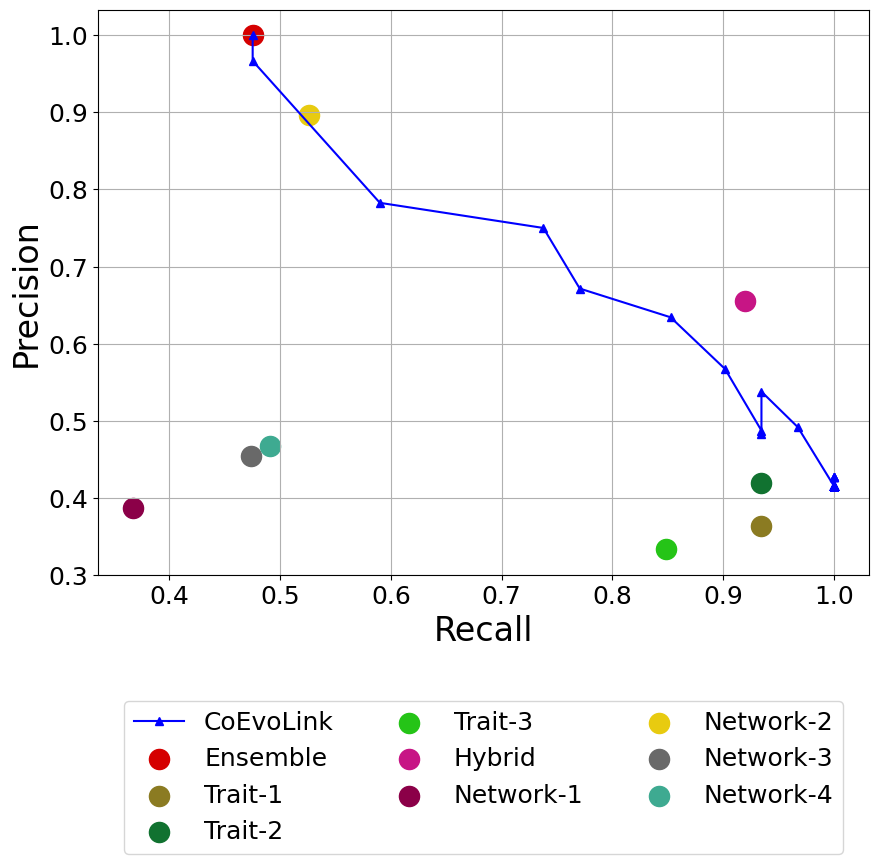

In [24]:
# --- Plot PR curve of your λ sweep ---
plt.figure(figsize=(9,9))

# sort curve_df by recall
curve_sorted = curve_df.sort_values("recall")
virion_curve_sorted = virion_curve_df.sort_values("recall")
curve_root_sorted = curve_root_df.sort_values("recall")
curve_root_sorted_algo = curve_root_df_algo.sort_values("recall")

# plt.plot(virion_curve_sorted["recall"], virion_curve_sorted["precision"], marker="x",
#          label="Virion benchmark", color="red")
# plt.plot(curve_sorted["recall"], curve_sorted["precision"], marker="o",
#          label="CoEvoLink", color="blue")
# plt.plot(curve_root_sorted["recall"], curve_root_sorted["precision"], marker="s",
#          label="Our method (root-level)", color="green")
plt.plot(curve_sorted["recall"], curve_sorted["precision"], marker="^",
         label="CoEvoLink", color="blue")
# annotate λ values
# for i, row in curve_sorted.iterrows():
#     plt.text(row["recall"], row["precision"], f"{row['lambda']:.2f}",
#              fontsize=7, color="blue")

# --- Overlay other models ---

# "ensemble": "Ensemble",
#     "model1": "Trait.1",
#     "model2": "Trait.2",
#     "model3": "Trait.3",
#     "model4": "Hybrid",
#     "model5": "Network.1",
#     "model6": "Network.2",
#     "model7": "Network.3",
#     "model8": "Network.4",
colors = {
    "ensemble": "#D50000",   # dark orange
    "model1": "#8B7B22",     # forest green
    "model2": "#117230",     # purple
    "model3": "#25C417",     # brown
    "model4": "#C71585",     # deep pink
    "model5": "#8B0048",     # dark cyan
    "model6": "#E8CB10",     # dark magenta
    "model7": "#696969",     # dim gray
    "model8": "#3EAA91",     # olive drab
}

for i, (model_name, sets) in enumerate(virion_sets.items()):
    plt.scatter(sets["recall"], sets["precision"], label=model_columns[model_name].replace('.', '-'), s=210, color=colors[model_name])

try:
    if 'elbow_recall' in globals() and 'elbow_precision' in globals():
        plt.scatter([elbow_recall], [elbow_precision], marker='*', s=400, color='gold', edgecolor='k', zorder=10, label='Elbow Point')
        # plt.text(elbow_recall, elbow_precision, ' Elbow', va='center', ha='left', fontsize=9, fontweight='bold')
except Exception:
    pass

# --- Final plot formatting ---
plt.xlabel("Recall", fontsize=24)
plt.ylabel("Precision", fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.title("Precision–Recall Comparison (CoEvoLink vs. Benchmark Models)")
plt.legend(bbox_to_anchor=(0.5, -0.2), loc="upper center", ncol=3, fontsize=18)
plt.tight_layout()
plt.grid(True)
plt.savefig(os.path.join(outdir, f"all_model_precision_recall_curve_{model_columns[MODEL]}.svg"), dpi=300)

last point: recall=1.0, precision=0.3297297297297297
Saved: experiments/aupc_curve_Ensemble.svg


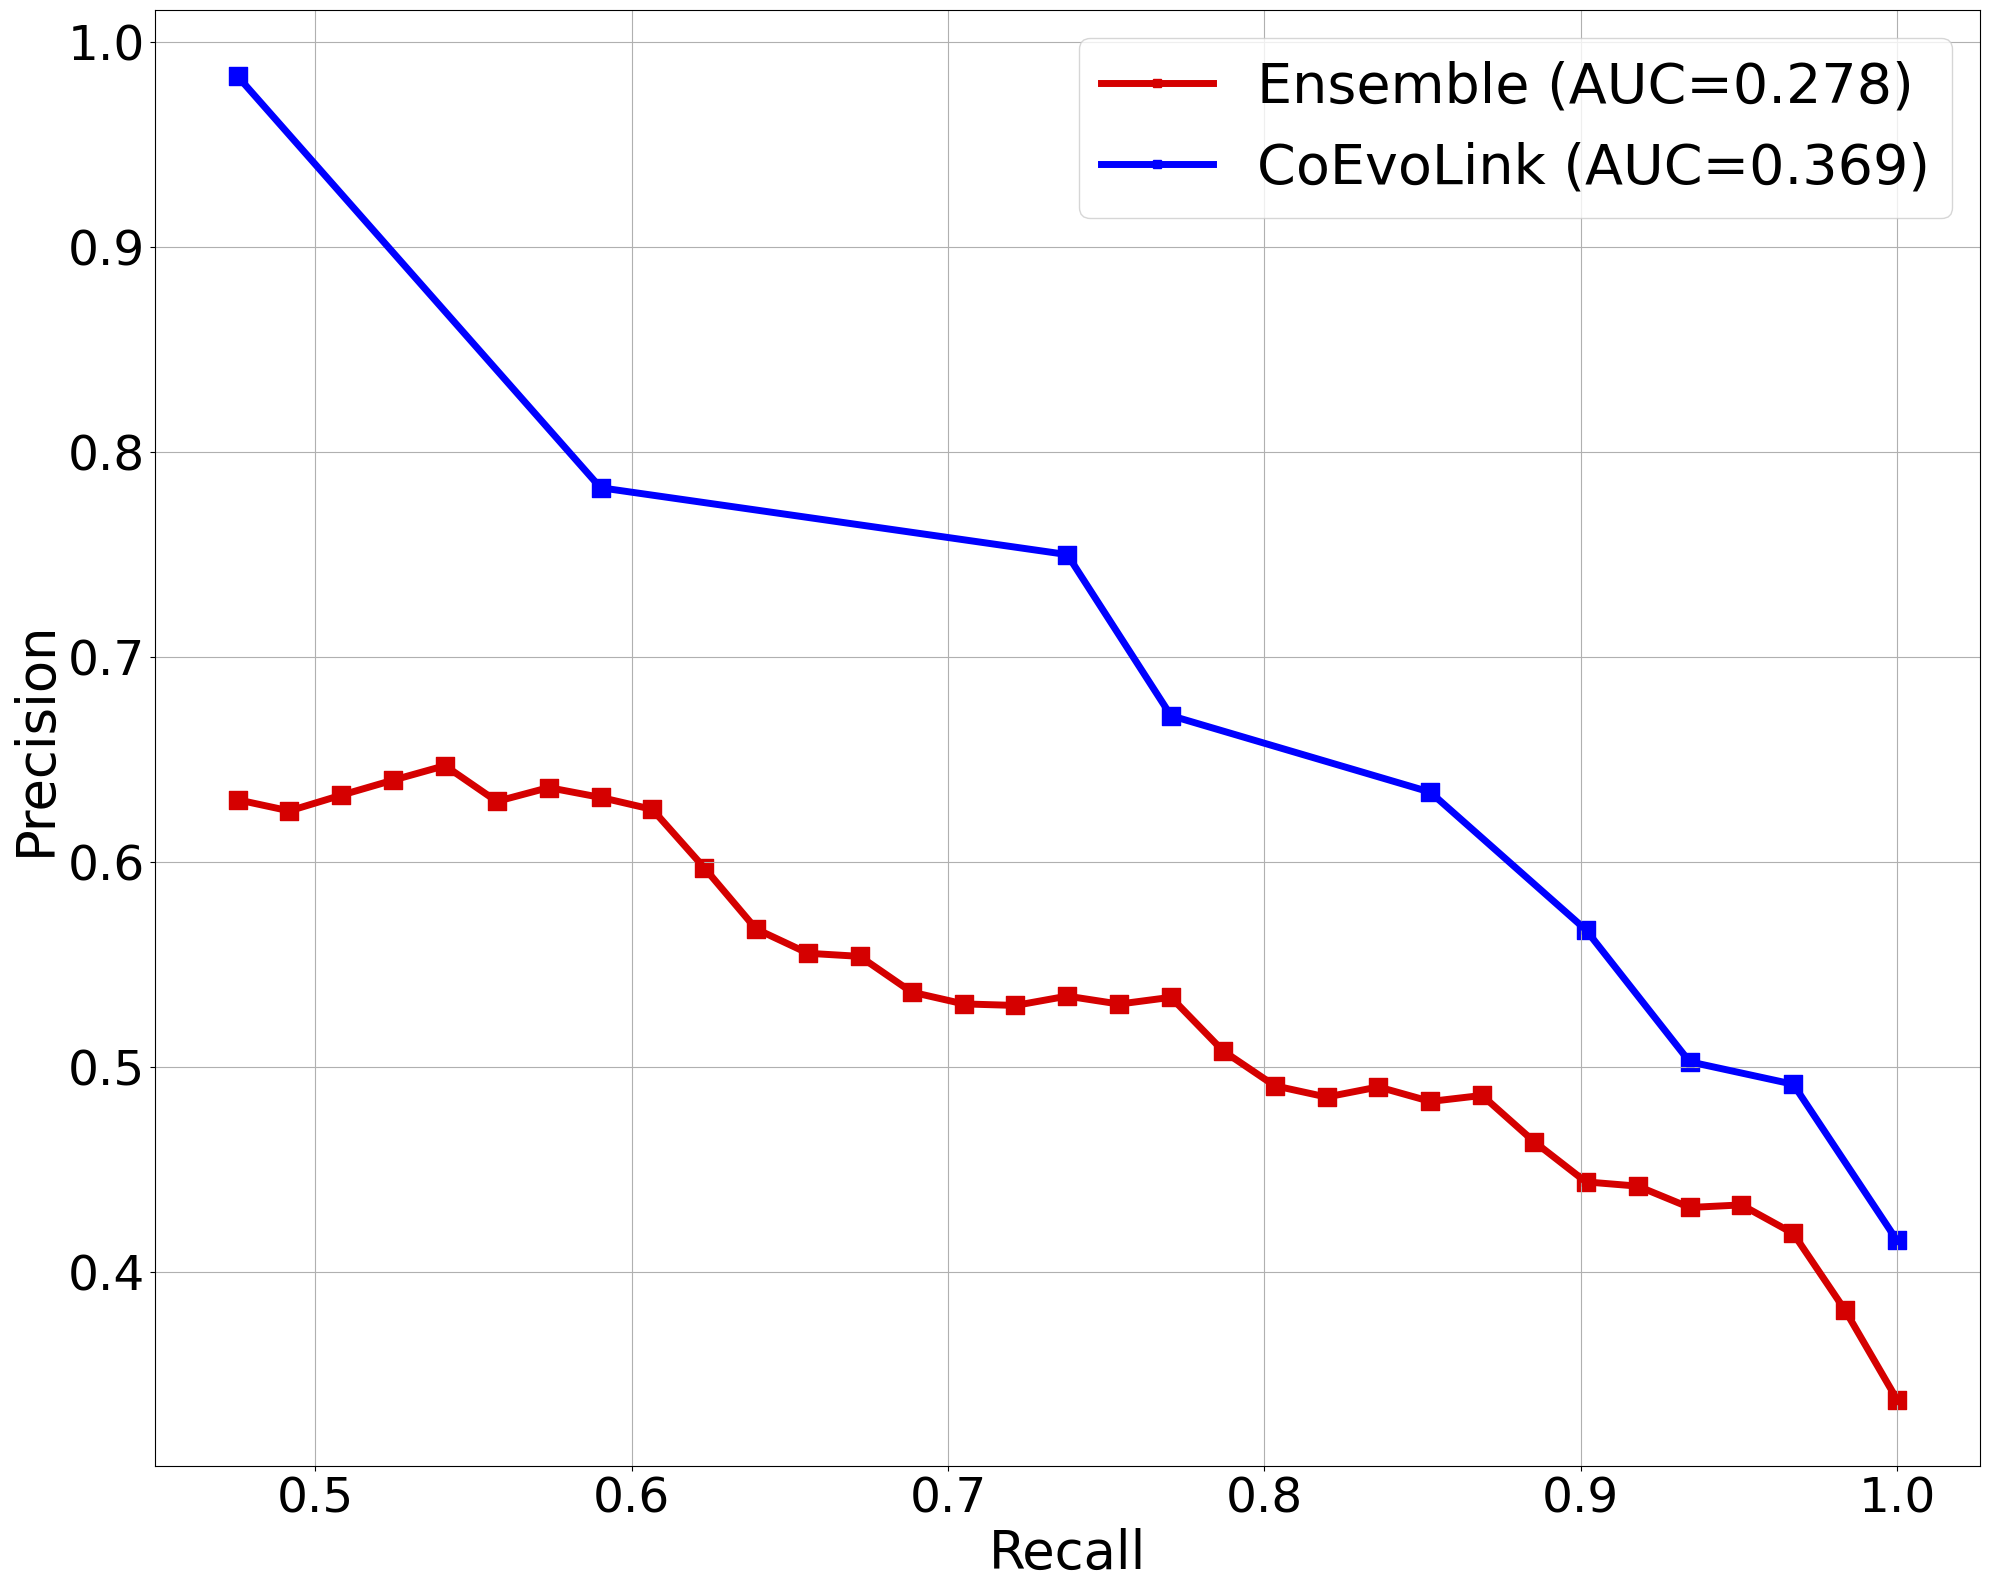

In [28]:
from sklearn.metrics import auc

plt.figure(figsize=(20,16))

# sort curve_df by recall
curve_sorted = curve_df.sort_values("recall")
virion_curve_sorted = virion_curve_df.sort_values("recall")
curve_root_sorted = curve_root_df.sort_values("recall")
curve_root_sorted_algo = curve_root_df_algo.sort_values("recall")

# Helper: for each rounded recall, compute mean precision and two precisions closest to the mean
def three_precisions_per_recall(df, recall_col='recall', precision_col='precision', round_digits=6):
    tmp = df.copy()
    tmp['recall_round'] = tmp[recall_col].round(round_digits)
    groups = tmp.groupby('recall_round')
    recs, means, close1, close2, counts = [], [], [], [], []
    for recall_val, group in groups:
        precisions = group[precision_col].astype(float).values
        counts.append(len(precisions))
        if len(precisions) == 0:
            mean_p = c1 = c2 = 0.0
        else:
            mean_p = float(np.mean(precisions))
            d = np.abs(precisions - mean_p)
            idx = np.argsort(d)
            if len(idx) >= 2:
                c1, c2 = float(precisions[idx[0]]), float(precisions[idx[1]])
            elif len(idx) == 1:
                c1 = c2 = float(precisions[idx[0]])
            else:
                c1 = c2 = 0.0
        recs.append(float(recall_val))
        means.append(mean_p)
        close1.append(c1)
        close2.append(c2)
    return pd.DataFrame({
        'recall': recs,
        'precision_mean': means,
        'precision_close_1': close1,
        'precision_close_2': close2,
        'n_points': counts
    }).sort_values('recall').reset_index(drop=True)

# Compute three-point stats for our method


# --- Ensemble overlay ---
import os
ens_csv = "ensemble_pr_curve.csv"
auc_ensemble = None

if os.path.exists(ens_csv):
    try:
        ens_df = pd.read_csv(ens_csv)
        if set(["precision", "recall"]).issubset(set(ens_df.columns)):
            ens_sorted = ens_df.sort_values("recall").reset_index(drop=True)
            our_start = curve_sorted.iloc[0][["recall", "precision"]].values.astype(float)
            ens_points_all = ens_sorted[["recall", "precision"]].values.astype(float)
            dists = np.linalg.norm(ens_points_all - our_start, axis=1)
            # match_idx = int(np.argmin(dists)+223)  # only for ensemble to start from same points
            match_idx = int(np.argmin(dists)+38)
            # 
            # match_idx = int(np.argmin(dists))
            ens_plot = ens_sorted.iloc[match_idx:].reset_index(drop=True)
            ens_three = three_precisions_per_recall(ens_plot, round_digits=6)

            
            # add some points at the end to reach (1.0, 0.0)
            if ens_three['recall'].values[-1] < 1.0:
                ens_three = pd.concat([
                    ens_three,
                    pd.DataFrame({
                        'recall': [1.0],
                        'precision_mean': [0.0],
                        'precision_close_1': [0.0],
                        'precision_close_2': [0.0],
                        'n_points': [0]
                    })
                ]).reset_index(drop=True)
            # --- Compute AUC for Ensemble ---
            auc_ensemble = auc(ens_three['recall'], ens_three['precision_mean'])
            

            plt.plot(ens_three['recall'], ens_three['precision_mean'],
                     color=colors[MODEL], marker='s', linestyle='-', linewidth=5,
                     label=f'Ensemble (AUC={auc_ensemble:.3f})')
            plt.scatter(ens_three['recall'], ens_three['precision_mean'],
                        color=colors[MODEL], s=150, marker='s', label=None)

            p = ens_sorted['precision'].values[-1]
            r = ens_sorted['recall'].values[-1]
            print(f"last point: recall={r}, precision={p}")
        else:
            print(f"CSV missing precision/recall columns: {ens_df.columns.tolist()}")
    except Exception as e:
        print(f"Error reading {ens_csv}: {e}")
else:
    print(f"{ens_csv} not found - skipping ensemble overlay")


# our_points = three_precisions_per_recall(pd.concat([curve_sorted[7:13], curve_sorted[16:]]), round_digits=6)
our_points = three_precisions_per_recall(curve_sorted, round_digits=6)
# our_points = curve_sorted.copy()

tol = 1e-3

# Boolean mask: True for points to keep
keep_mask = []

# Ensemble coordinates
ens_coords = ens_sorted[['recall', 'precision']].values

# Loop over our_points and remove any point that matches Ensemble
# for i, row in our_points.iterrows():
#     r, p = row['recall'], row['precision']
#     dists = np.linalg.norm(ens_coords - np.array([r, p]), axis=1)
#     if np.any(dists < tol):
#         keep_mask.append(False)  # too close to ensemble, remove
#     else:
#         keep_mask.append(True)

# Filter our_points
# our_points = our_points[keep_mask]
# our_points = curve_root_sorted_algo

# --- Compute AUC for CoEvoLink ---
auc_coevo = auc(our_points['recall'], our_points['precision_mean'])
# auc_coevo = auc(curve_root_sorted_algo['recall'], curve_root_sorted_algo['precision'])

# Plot aggregated mean line (only) for our method, increase thickness of the line
plt.plot(our_points['recall'], our_points['precision_mean'], marker='s',
         linestyle='-', label=f'CoEvoLink (AUC={auc_coevo:.3f})', color='blue', linewidth=5)
plt.scatter(our_points['recall'], our_points['precision_mean'], color='blue', s=150, marker='s', label=None)
# plt.plot(curve_root_sorted_algo['recall'], curve_root_sorted_algo['precision'], marker='^',
#          linestyle='-', label=f'CoEvoLink (AUC={auc_coevo:.3f})', color='blue')
# plt.scatter(curve_root_sorted_algo['recall'], curve_root_sorted_algo['precision'], color='blue', s=40, marker='^', label=None)

# --- Final plot formatting ---
plt.xlabel("Recall", fontsize=38)
plt.ylabel("Precision", fontsize=38)
plt.xticks(fontsize=35)
plt.yticks(fontsize=35)
plt.legend(loc="upper right", fontsize=40)
plt.grid(True)
plt.tight_layout()

outpath = os.path.join(outdir, f"aupc_curve_{model_columns[MODEL]}.svg")
plt.savefig(outpath, dpi=300)
print('Saved:', outpath)
plt.show()


In [30]:
# Example: you already have a list of hosts (in desired order)
# fn_hosts = sorted(fn_hosts, key=lambda h: hosts.index(h))

# Filter host taxonomy rows based on fn_hosts
host_ids = [h.split("_", 1)[1] if "_" in h else h for h in fn_hosts]

# Filter rows
filtered_host_tax = host_tax[host_tax["HostTaxID"].isin(host_ids)].copy()

# Preserve order based on fn_hosts
filtered_host_tax["sort_order"] = filtered_host_tax["HostTaxID"].apply(
    lambda x: fn_hosts.index(x) if x in fn_hosts else -1
)
filtered_host_tax = filtered_host_tax.sort_values("sort_order").drop(columns="sort_order")

# Save to CSV
filtered_host_tax.to_csv("filtered_host_taxonomy.csv", index=False)

print(f"Saved {len(filtered_host_tax)} matching host rows in fn_hosts order to filtered_host_taxonomy.csv")

# Extract clean virus IDs from parasites (remove prefix like "virus_")
parasite_ids = [v.split("_", 1)[1] if "_" in v else v for v in parasites]

# Filter only matching rows
filtered_virus_tax = virus_tax[virus_tax['VirusTaxID'].isin(parasite_ids)].copy()

# Preserve order based on parasites list
filtered_virus_tax["sort_order"] = filtered_virus_tax["VirusTaxID"].apply(
    lambda x: parasite_ids.index(x) if x in parasite_ids else -1
)
filtered_virus_tax = filtered_virus_tax.sort_values("sort_order").drop(columns="sort_order")



# Save to CSV
filtered_virus_tax.to_csv("filtered_virus_taxonomy.csv", index=False)

print(f"Saved {len(filtered_virus_tax)} matching virus rows in parasite order to filtered_virus_taxonomy.csv")

Saved 24 matching host rows in fn_hosts order to filtered_host_taxonomy.csv
Saved 22 matching virus rows in parasite order to filtered_virus_taxonomy.csv


In [24]:
import pandas as pd

# Read the virion data
# use other encoding if needed, e.g., 'utf-8', 'latin1', etc.
virion = pd.read_csv("../../virion.csv", dtype=str, encoding='latin1').fillna("")

# Prepare parasite IDs (already done)
# parasite_ids = [v.split("_", 1)[1] if "_" in v else v for v in parasites]

# Filter rows where VirusTaxID matches AND Host == "homo sapiens" (case-insensitive)
filtered = virion[
    virion["VirusTaxID"].isin(parasite_ids) &
    (virion["Host"].str.lower() == "homo sapiens")
].copy()

# Save result
filtered.to_csv("filtered_human_virion.csv", index=False)

print(f"Saved {len(filtered)} rows with Host='homo sapiens' to filtered_human_virion.csv")

Saved 218507 rows with Host='homo sapiens' to filtered_human_virion.csv


In [31]:
# --- Keep only VirusTaxIDs that have at least 3 entries ---
counts = filtered["VirusTaxID"].value_counts()
print (counts)
valid_viruses = counts[counts >= 1].index
filtered = filtered[filtered["VirusTaxID"].isin(valid_viruses)]

print(f"After keeping viruses with ≥3 human entries: {len(filtered)} rows, {len(valid_viruses)} viruses")

# --- Sample up to 100 entries total, stratified by VirusTaxID ---
# To ensure fair representation, sample proportionally by virus but at least 3 per virus
grouped = (
    filtered.groupby("VirusTaxID", group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), 1), random_state=42))
)

# If still >100 after ensuring 3 per virus, sample down to 100
grouped = grouped.sample(n=3, random_state=42)

# Save the final subset
grouped.to_csv("filtered_human_virion_sampled.csv", index=False)

print(f"Saved {len(grouped)} sampled rows (≥3 per virus) to filtered_human_virion_sampled.csv")

VirusTaxID
3418604    217665
3433757       731
694009        111
Name: count, dtype: int64
After keeping viruses with ≥3 human entries: 218507 rows, 3 viruses
Saved 3 sampled rows (≥3 per virus) to filtered_human_virion_sampled.csv


/var/folders/81/_4qkc5w17kd767vqrndc8k440000gp/T/ipykernel_11099/2970774870.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 1), random_state=42))


In [ ]:
# model precision-recall curve


plt.figure(figsize=(7,7))

# sort curve_df by recall
curve_sorted = curve_df.sort_values("recall")
virion_curve_sorted = virion_curve_df.sort_values("recall")
curve_root_sorted = curve_root_df.sort_values("recall")
curve_root_sorted_algo = curve_root_df_algo.sort_values("recall")

# Helper: for each rounded recall, compute mean precision and two precisions closest to the mean
def three_precisions_per_recall(df, recall_col='recall', precision_col='precision', round_digits=6):
    tmp = df.copy()
    tmp['recall_round'] = tmp[recall_col].round(round_digits)
    groups = tmp.groupby('recall_round')
    recs = []
    means = []
    close1 = []
    close2 = []
    counts = []
    for recall_val, group in groups:
        precisions = group[precision_col].astype(float).values
        counts.append(len(precisions))
        if len(precisions) == 0:
            mean_p = 0.0
            c1 = 0.0
            c2 = 0.0
        else:
            mean_p = float(np.mean(precisions))
            d = np.abs(precisions - mean_p)
            idx = np.argsort(d)
            if len(idx) >= 2:
                c1 = float(precisions[idx[0]])
                c2 = float(precisions[idx[1]])
            elif len(idx) == 1:
                c1 = float(precisions[idx[0]])
                c2 = float(precisions[idx[0]])
            else:
                c1 = 0.0; c2 = 0.0
        recs.append(float(recall_val))
        means.append(mean_p)
        close1.append(c1)
        close2.append(c2)
    out = pd.DataFrame({
        'recall': recs,
        'precision_mean': means,
        'precision_close_1': close1,
        'precision_close_2': close2,
        'n_points': counts
    }).sort_values('recall').reset_index(drop=True)
    return out

# Compute three-point stats for our method
our_points = three_precisions_per_recall(curve_sorted, round_digits=6)

# Plot aggregated mean line (only) for our method
plt.plot(our_points['recall'], our_points['precision_mean'], marker=None,
         linestyle='-', label='CoEvoLink', color='blue')
# Plot the three points (mean + two closest) for our method
plt.scatter(our_points['recall'], our_points['precision_close_1'], color='cyan', s=40, marker='s', alpha=0.9, label=None)
plt.scatter(our_points['recall'], our_points['precision_close_2'], color='deepskyblue', s=40, marker='s', alpha=0.9, label=None)
plt.scatter(our_points['recall'], our_points['precision_mean'], color='blue', s=40, marker='s', label=None)


# Attempt to overlay ensemble PR curve from CSV, starting where it best matches our starting point
import os
ens_csv = "model6_pr_curve.csv"
if os.path.exists(ens_csv):
    try:
        ens_df = pd.read_csv(ens_csv)
        # ensure required cols
        if set(["precision", "recall"]).issubset(set(ens_df.columns)):
            ens_sorted = ens_df.sort_values("recall").reset_index(drop=True)
            # our starting point (lowest-recall point from our curve)
            our_start = curve_sorted.iloc[0][["recall", "precision"]].values.astype(float)
            print ("Our starting point (recall, precision):", our_start)
            # ensemble points
            ens_points_all = ens_sorted[["recall", "precision"]].values.astype(float)
            # Euclidean distance
            dists = np.linalg.norm(ens_points_all - our_start, axis=1)
            match_idx = int(np.argmin(dists))
            # Prepare ensemble plotted subset (preserve match behavior)
            ens_plot = ens_sorted.iloc[match_idx:].reset_index(drop=True)
            
            # Compute three-point stats restricted to the plotted ensemble range
            ens_three = three_precisions_per_recall(ens_plot, round_digits=6)

            # Plot aggregated mean line for ensemble (only across plotted range)
            plt.plot(ens_plot['recall'], ens_plot['precision'], marker='s', linestyle='-',
                     label='Network.2', color='red')

            # Plot ensemble three points
            # plt.scatter(ens_three['recall'], ens_three['precision_close_1'], color='lightcoral', s=40, marker='s', alpha=0.9, label=None)
            # plt.scatter(ens_three['recall'], ens_three['precision_close_2'], color='salmon', s=40, marker='s', alpha=0.9, label=None)
            # plt.scatter(ens_three['recall'], ens_three['precision_mean'], color='red', s=40, marker='s', label=None)


            # plot some dummy precision and recall
            # plt.plot([0.1, 0.2, 0.3], [0.9, 0.8, 0.7], color='red', marker='s',  linestyle='-')

            # (Do NOT change the starting-point/match logic - preserved above)
        else:
            print(f"CSV does not contain precision/recall columns: {ens_df.columns.tolist()}")
    except Exception as e:
        print(f"Error reading {ens_csv}: {e}")
else:
    print(f"{ens_csv} not found - skipping ensemble overlay")

# --- Final plot formatting ---
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Comparison (CoEvoLink vs. Network.2 Model)")
plt.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=2)
plt.tight_layout()
plt.grid(True)
outpath = os.path.join(outdir, "precision_recall_curve_only_model6.svg")
plt.savefig(outpath, dpi=300)
print('Saved:', outpath)
plt.show()